<a href="https://colab.research.google.com/github/ajsarsva/video-captioning-thesis/blob/main/notebooks/day17b_bertscore_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Master setup cell

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('/content/drive/MyDrive/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

if os.path.exists('/content/video-captioning-thesis'):
    %cd /content/video-captioning-thesis
    !git pull origin main
else:
    !git clone https://github.com/ajsarsva/video-captioning-thesis.git
    %cd /content/video-captioning-thesis

import sys
sys.path.append('/content/video-captioning-thesis/src')

print("✅ Ready!")

Mounted at /content/drive
Cloning into 'video-captioning-thesis'...
remote: Enumerating objects: 109, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 109 (delta 58), reused 27 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (109/109), 19.85 MiB | 16.00 MiB/s, done.
Resolving deltas: 100% (58/58), done.
/content/video-captioning-thesis
✅ Ready!


In [2]:
!pip install bert-score -q
!pip install transformers -q

import json
import numpy as np
import os
import sys
sys.path.append('/content/video-captioning-thesis/src')

print("✅ Libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.3 MB/s eta 0:00:00
✅ Libraries installed!


Data Loading

In [3]:
# Load all results
with open('/content/drive/MyDrive/thesis-data/MSR_VTT.json') as f:
    gt_data = json.load(f)
with open('/content/drive/MyDrive/thesis-data/captions/strategy_A_full.json') as f:
    results_a = json.load(f)
with open('/content/drive/MyDrive/thesis-data/captions/strategy_B_full.json') as f:
    results_b = json.load(f)
with open('/content/drive/MyDrive/thesis-data/captions/strategy_C_full.json') as f:
    results_c = json.load(f)

# Build ground truth lookup
ground_truth = {}
for ann in gt_data['annotations']:
    vid = ann['image_id']
    if vid not in ground_truth:
        ground_truth[vid] = []
    ground_truth[vid].append(ann['caption'])

print(f"Loaded {len(ground_truth)} videos with ground truth")
print(f"Strategy A: {len(results_a)} captions")
print(f"Strategy B: {len(results_b)} captions")
print(f"Strategy C: {len(results_c)} captions")

Loaded 10000 videos with ground truth
Strategy A: 7010 captions
Strategy B: 7010 captions
Strategy C: 7010 captions


BERTScore Evaluation Function

In [4]:
from bert_score import score as bert_score
import torch

def evaluate_bertscore(results, ground_truth, sample_size=1000, batch_size=64):
    """
    Evaluate BERTScore for a strategy.

    BERTScore compares semantic meaning using BERT embeddings.
    Unlike BLEU/CIDEr it rewards semantically correct captions
    even if they use different words than references.

    For each video:
    - Compare generated caption against ALL reference captions
    - Take the maximum score (best matching reference)

    Args:
        sample_size: number of videos to evaluate (1000 is enough)
        batch_size: process this many at once
    """

    # Sample videos
    video_ids = [vid for vid in list(results.keys())[:sample_size]
                 if vid in ground_truth
                 and results[vid]['caption'].strip()]

    print(f"  Evaluating on {len(video_ids)} videos...")

    all_precision = []
    all_recall = []
    all_f1 = []

    # Process in batches
    for batch_start in range(0, len(video_ids), batch_size):
        batch_ids = video_ids[batch_start:batch_start+batch_size]

        candidates = []
        references = []

        for vid in batch_ids:
            caption = results[vid]['caption']
            # Use first 5 reference captions
            refs = ground_truth[vid][:5]

            # Add one candidate per reference for comparison
            for ref in refs:
                candidates.append(caption)
                references.append(ref)

        # Compute BERTScore
        P, R, F1 = bert_score(
            candidates,
            references,
            lang='en',
            verbose=False,
            device='cuda' if torch.cuda.is_available() else 'cpu'
        )

        # For each video, take max F1 across its references
        idx = 0
        for vid in batch_ids:
            n_refs = len(ground_truth[vid][:5])
            video_f1 = F1[idx:idx+n_refs]
            video_p = P[idx:idx+n_refs]
            video_r = R[idx:idx+n_refs]

            all_f1.append(video_f1.max().item())
            all_precision.append(video_p.max().item())
            all_recall.append(video_r.max().item())
            idx += n_refs

        if (batch_start + batch_size) % 200 == 0:
            print(f"  {min(batch_start+batch_size, len(video_ids))}"
                  f"/{len(video_ids)} done | "
                  f"avg F1: {np.mean(all_f1):.4f}")

    return {
        'BERTScore_P': round(np.mean(all_precision) * 100, 2),
        'BERTScore_R': round(np.mean(all_recall) * 100, 2),
        'BERTScore_F1': round(np.mean(all_f1) * 100, 2),
        'videos_evaluated': len(video_ids)
    }

Run of BERTScore on All Three Strategies

In [5]:
import time

print("=" * 50)
print("Running BERTScore Evaluation")
print("=" * 50)

print("\nStrategy A (Uniform)...")
start = time.time()
bert_a = evaluate_bertscore(results_a, ground_truth, sample_size=1000)
print(f"Done in {(time.time()-start)/60:.1f} min")

print("\nStrategy B (SSIM)...")
start = time.time()
bert_b = evaluate_bertscore(results_b, ground_truth, sample_size=1000)
print(f"Done in {(time.time()-start)/60:.1f} min")

print("\nStrategy C (CLIP)...")
start = time.time()
bert_c = evaluate_bertscore(results_c, ground_truth, sample_size=1000)
print(f"Done in {(time.time()-start)/60:.1f} min")

Running BERTScore Evaluation

Strategy A (Uniform)...
  Evaluating on 1000 videos...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Done in 0.9 min


Combined Results Table

In [8]:
# Load existing scores
with open('/content/drive/MyDrive/thesis-data/results/evaluation_scores.json') as f:
    existing_scores = json.load(f)

print("\n")
print("=" * 85)
print("COMPLETE EVALUATION TABLE")
print("=" * 85)
print(f"{'Strategy':<25} {'BLEU-1':>7} {'BLEU-4':>7} {'METEOR':>7} "
      f"{'ROUGE-L':>8} {'CIDEr':>7} {'BERT-R':>8}")
print("-" * 85)

strategies = [
    ('A — Uniform (K=8)',     existing_scores['Strategy_A'], bert_a),
    ('B — SSIM (θ=0.7)',      existing_scores['Strategy_B'], bert_b),
    ('C — CLIP K-Means (K=8)',existing_scores['Strategy_C'], bert_c),
]

for name, scores, bert in strategies:
    print(f"{name:<25} "
          f"{scores['BLEU-1']:>7} "
          f"{scores['BLEU-4']:>7} "
          f"{scores['METEOR']:>7} "
          f"{scores['ROUGE-L']:>8} "
          f"{scores['CIDEr']:>7} "
          f"{bert['BERTScore_R']:>8}")

print("=" * 85)
print("\nBERT-R measures semantic recall — how much of the reference meaning is captured")



COMPLETE EVALUATION TABLE
Strategy                   BLEU-1  BLEU-4  METEOR  ROUGE-L   CIDEr   BERT-R
-------------------------------------------------------------------------------------
A — Uniform (K=8)           64.38   20.14    21.1    46.85   28.07    91.63
B — SSIM (θ=0.7)            62.69   18.77   20.01    45.76   24.81    91.47
C — CLIP K-Means (K=8)       63.8   19.62   20.76     46.5   26.74    91.59

BERT-R measures semantic recall — how much of the reference meaning is captured


Plots

BERTScore results saved!


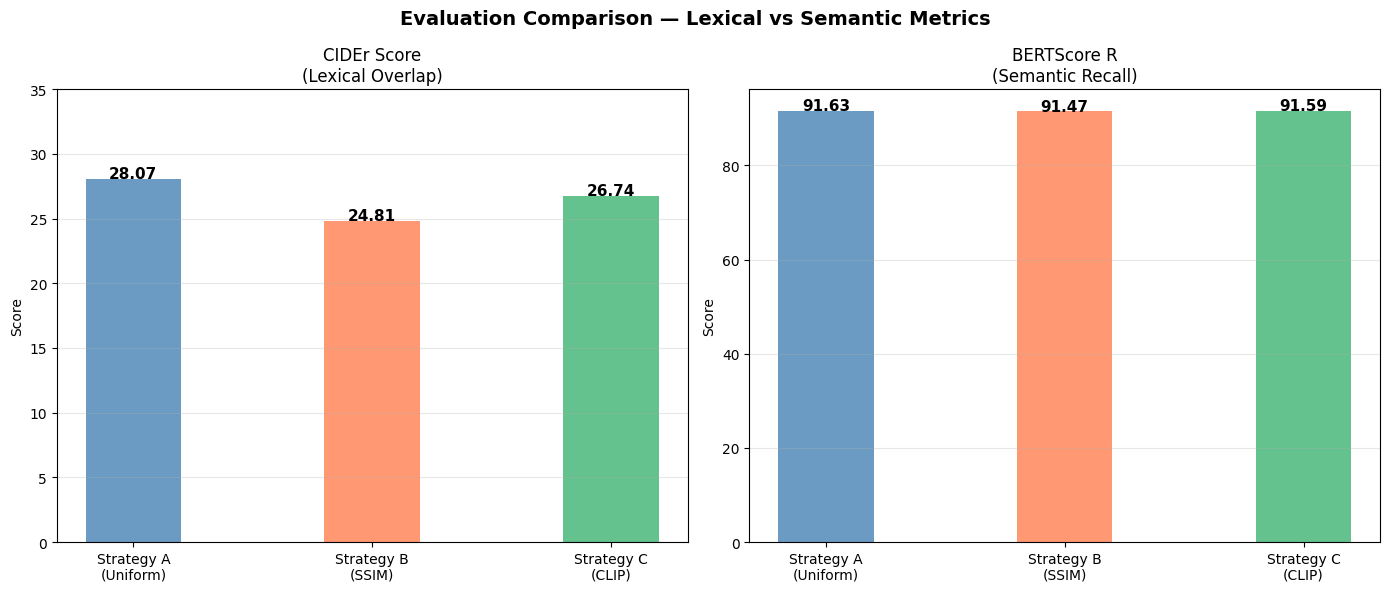

Comparison plot saved!


In [9]:
# Save BERTScore results
bert_results = {
    'Strategy_A': bert_a,
    'Strategy_B': bert_b,
    'Strategy_C': bert_c
}

with open('/content/drive/MyDrive/thesis-data/results/bertscore_results.json', 'w') as f:
    json.dump(bert_results, f, indent=2)

print("BERTScore results saved!")

# Plot comparison
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Evaluation Comparison — Lexical vs Semantic Metrics',
             fontsize=14, fontweight='bold')

strategies = ['Strategy A\n(Uniform)', 'Strategy B\n(SSIM)', 'Strategy C\n(CLIP)']
colors = ['steelblue', 'coral', 'mediumseagreen']
x = np.arange(3)

# Plot 1 — CIDEr (lexical)
cider_scores = [existing_scores['Strategy_A']['CIDEr'],
                existing_scores['Strategy_B']['CIDEr'],
                existing_scores['Strategy_C']['CIDEr']]

bars = axes[0].bar(x, cider_scores, color=colors, alpha=0.8, width=0.4)
for bar, val in zip(bars, cider_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('CIDEr Score\n(Lexical Overlap)', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(strategies)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 35)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2 — BERTScore R (semantic)
bert_f1_scores = [bert_a['BERTScore_R'],
                  bert_b['BERTScore_R'],
                  bert_c['BERTScore_R']]

bars = axes[1].bar(x, bert_f1_scores, color=colors, alpha=0.8, width=0.4)
for bar, val in zip(bars, bert_f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('BERTScore R\n(Semantic Recall)', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(strategies)
axes[1].set_ylabel('Score')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis-data/figures/lexical_vs_semantic.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Comparison plot saved!")